In [1]:
# Importing Libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os
import numpy as np
import warnings
warnings.filterwarnings('ignore')



In [2]:
# Running Complete Preprocessing Pipeline

import sys                  # sys module lets us modify where Python

sys.path.append('..')

from src.preprocess import run_preprocessing_pipeline

df_raw, df_clean, df_encoded, feature_columns = run_preprocessing_pipeline('../data/raw/telco_churn.csv')

print(f"\n Variables ready to use:")
print(f"df_raw shape:      {df_raw.shape}")
print(f"df_clean shape:    {df_clean.shape}")
print(f"df_encoded shape:  {df_encoded.shape}")
print(f"Feature columns:   {len(feature_columns)}")

  PREPROCESSING PIPELINE STARTING

 STEP 1: Loading data...
Data loaded!
   Rows: 7043, Columns: 21

 STEP 2: Cleaning data...
Fixed TotalCharges: dropped 11 empty rows
Dropped customerID column
Churn encoded: Yes→1, No→0
Cleaning done: 7032 rows, 20 columns

 STEP 3: Encoding features...
   Found 15 text columns to encode
   Columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']
Encoding done: 31 total columns
   Feature columns: 30

 STEP 4: Saving processed data...
Saved to: ../data/processed/telco_churn_cleaned.csv

  PIPELINE COMPLETE!
  Raw data:     7043 rows, 21 cols
  Clean data:   7032 rows, 20 cols
  Encoded data: 7032 rows, 31 cols
  Features:     30 columns

 Variables ready to use:
df_raw shape:      (7043, 21)
df_clean shape:    (7032, 20)
df_encoded shape:  (7032, 31)
Feature col

In [3]:
# First Look at Raw Data
print("Dataset Info:")
df_raw.info()

print('\n')

print('Unique values per column:')
display(df_raw.nunique())

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-n

customerID          7043
gender                 2
SeniorCitizen          2
Partner                2
Dependents             2
tenure                73
PhoneService           2
MultipleLines          3
InternetService        3
OnlineSecurity         3
OnlineBackup           3
DeviceProtection       3
TechSupport            3
StreamingTV            3
StreamingMovies        3
Contract               3
PaperlessBilling       2
PaymentMethod          4
MonthlyCharges      1585
TotalCharges        6531
Churn                  2
dtype: int64

Churn
No     5174
Yes    1869
Name: count, dtype: int64
No : 5174 Customers (73.5%)
Yes : 1869 Customers (26.5%)



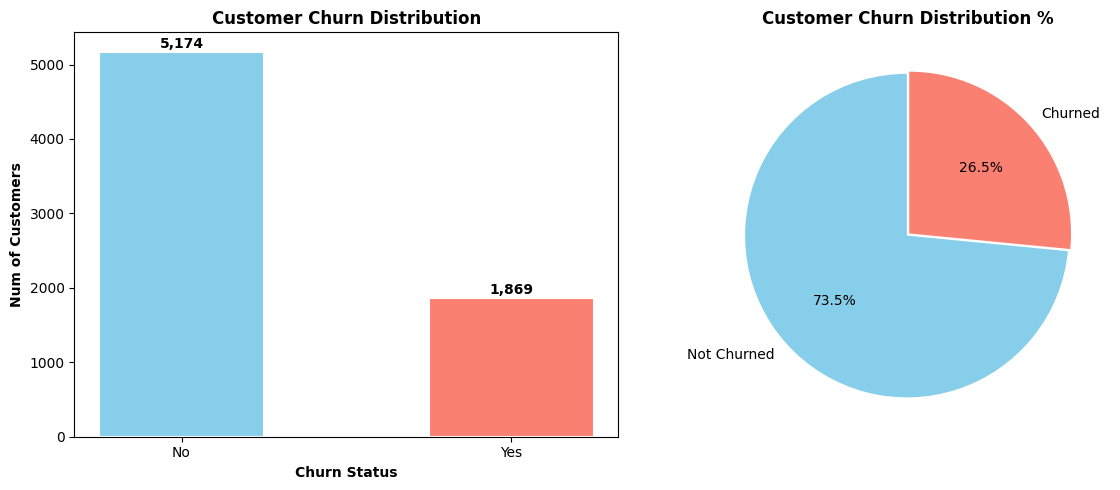

In [4]:
# Quick EDA: Class Imbalance
churn_counts = df_raw['Churn'].value_counts()
print(churn_counts)

for value, count in churn_counts.items():

    percentage = (count / (len(df_raw))) * 100
    print(f'{value} : {count} Customers ({percentage:.1f}%)')

print()

fig, ax = plt.subplots(1, 2, figsize = (12, 5))

#Bar Chart
bars = ax[0].bar(churn_counts.index, 
                 churn_counts.values, 
                 color = ['skyblue', 'salmon'],
                 edgecolor = 'white',
                 linewidth = 1.5, 
                 width = 0.5)

for bar, value in zip(bars, churn_counts.values):
    ax[0].text(bar.get_x() + bar.get_width()/2  ,
               bar.get_height() + 50,
               f'{value:,}',
               ha = 'center',
               fontweight = 'bold',
               fontsize = 10)
    
ax[0].set_title('Customer Churn Distribution', fontsize = 12, fontweight = 'bold')
ax[0].set_xlabel('Churn Status', fontsize = 10, fontweight = 'bold')
ax[0].set_ylabel('Num of Customers', fontsize = 10, fontweight = 'bold')

#Pie Chart
ax[1].pie(churn_counts.values, 
          labels = ['Not Churned', 'Churned'],
          autopct = '%1.1f%%',
          colors = ['skyblue', 'salmon'],
          startangle = 90,  
          explode = (0.01, 0.01)) 

ax[1].set_title('Customer Churn Distribution %', fontsize = 12, fontweight = 'bold')

plt.tight_layout()
plt.savefig('../outputs/01_churn_distribution.png',
            dpi=150, bbox_inches='tight')
plt.show()


In [5]:
# Complete Missing Value Audit
print("COMPLETE MISSING VALUE AUDIT")
print("=" * 55)

# Checking True NaN values
print("\n Checking True NaN Missing Values")
print("─" * 40)
true_missing = df_raw.isnull().sum()
true_missing_cols = true_missing[true_missing > 0]
if len(true_missing_cols) == 0:
    print("No true NaN missing values found!")
else:
    print(true_missing_cols)

# Checking Disguised missing values in text columns
print("\nChecking Disguised Missing in Text Columns")
print("─" * 40)
text_cols = df_raw.select_dtypes(include='object').columns
for col in text_cols:
    disguised = df_raw[col].str.strip().eq('').sum()
    placeholders = df_raw[col].str.lower().isin(
        ['n/a', 'na', 'none', 'unknown', 'null', '?', '-']
    ).sum()
    total = disguised + placeholders
    if total > 0:
        print(f"{col}: {total} disguised missing values")
    else:
        print(f"{col}: Clean")

# Checking Zeros in numerical columns
print("\nChecking Zero Values in Numerical Columns")
print("─" * 40)
num_cols = df_raw.select_dtypes(include=['int64','float64']).columns
for col in num_cols:
    zero_count = (df_raw[col] == 0).sum()
    if zero_count > 0:
        print(f"ℹ{col}: {zero_count} zeros "
              f"(verify if 0 is valid here)")

print("\nSUMMARY")
print("─" * 40)
print(f"Total rows: {len(df_raw)}")
print(f"Total columns: {len(df_raw.columns)}")
print(f"True NaN: {df_raw.isnull().sum().sum()}")


COMPLETE MISSING VALUE AUDIT

 Checking True NaN Missing Values
────────────────────────────────────────
No true NaN missing values found!

Checking Disguised Missing in Text Columns
────────────────────────────────────────
customerID: Clean
gender: Clean
Partner: Clean
Dependents: Clean
PhoneService: Clean
MultipleLines: Clean
InternetService: Clean
OnlineSecurity: Clean
OnlineBackup: Clean
DeviceProtection: Clean
TechSupport: Clean
StreamingTV: Clean
StreamingMovies: Clean
Contract: Clean
PaperlessBilling: Clean
PaymentMethod: Clean
TotalCharges: 11 disguised missing values
Churn: Clean

Checking Zero Values in Numerical Columns
────────────────────────────────────────
ℹSeniorCitizen: 5901 zeros (verify if 0 is valid here)
ℹtenure: 11 zeros (verify if 0 is valid here)

SUMMARY
────────────────────────────────────────
Total rows: 7043
Total columns: 21
True NaN: 0


In [6]:
# Basic Statistics
print("NUMERICAL COLUMNS SUMMARY:")
print("─" * 40)

display(df_raw.describe().round(2))

print("\nCATEGORICAL COLUMNS SUMMARY:")
print("─" * 40)

display(df_raw.describe(include='object'))

NUMERICAL COLUMNS SUMMARY:
────────────────────────────────────────


,SeniorCitizen,tenure,MonthlyCharges
count,7043.00,7043.00,7043.00
mean,0.16,32.37,64.76
std,0.37,24.56,30.09
min,0.00,0.00,18.25
25%,0.00,9.00,35.50
50%,0.00,29.00,70.35
75%,0.00,55.00,89.85
max,1.00,72.00,118.75



CATEGORICAL COLUMNS SUMMARY:
────────────────────────────────────────


,customerID,gender,Partner,Dependents,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,TotalCharges,Churn
count,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043,7043
unique,7043,2,2,2,2,3,3,3,3,3,3,3,3,3,2,4,6531,2
top,7590-VHVEG,Male,No,No,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,20.2,No
freq,1,3555,3641,4933,6361,3390,3096,3498,3088,3095,3473,2810,2785,3875,4171,2365,11,5174


In [7]:
# Final Cleaning Verification

print("CLEANING VERIFICATION:")
print("─" * 40)
print(f"Rows:                  {df_encoded.shape[0]}")
print(f"Columns:               {df_encoded.shape[1]}")
print(f"Missing values:        {df_encoded.isnull().sum().sum()}")
print(f"Churn values:          {df_encoded['Churn'].unique()}")
print(f"Text columns left:     "
      f"{len(df_encoded.select_dtypes(include='object').columns)}")

# Checking specific expected values
assert df_encoded.shape[0] == 7032, "Row count wrong!"
assert df_encoded.shape[1] < 100,   "Too many columns!"
assert df_encoded.isnull().sum().sum() == 0, "Missing values!"
assert df_encoded['Churn'].nunique() == 2, "Churn not encoded!"

print("\nAll checks passed")

CLEANING VERIFICATION:
────────────────────────────────────────
Rows:                  7032
Columns:               31
Missing values:        0
Churn values:          [0 1]
Text columns left:     0

All checks passed


CHURN RATE BY CONTRACT TYPE:
Churn                  0         1
Contract                          
Month-to-month  0.572903  0.427097
One year        0.887228  0.112772
Two year        0.971513  0.028487

Churn              0     1
Contract                  
Month-to-month  57.3  42.7
One year        88.7  11.3
Two year        97.2   2.8


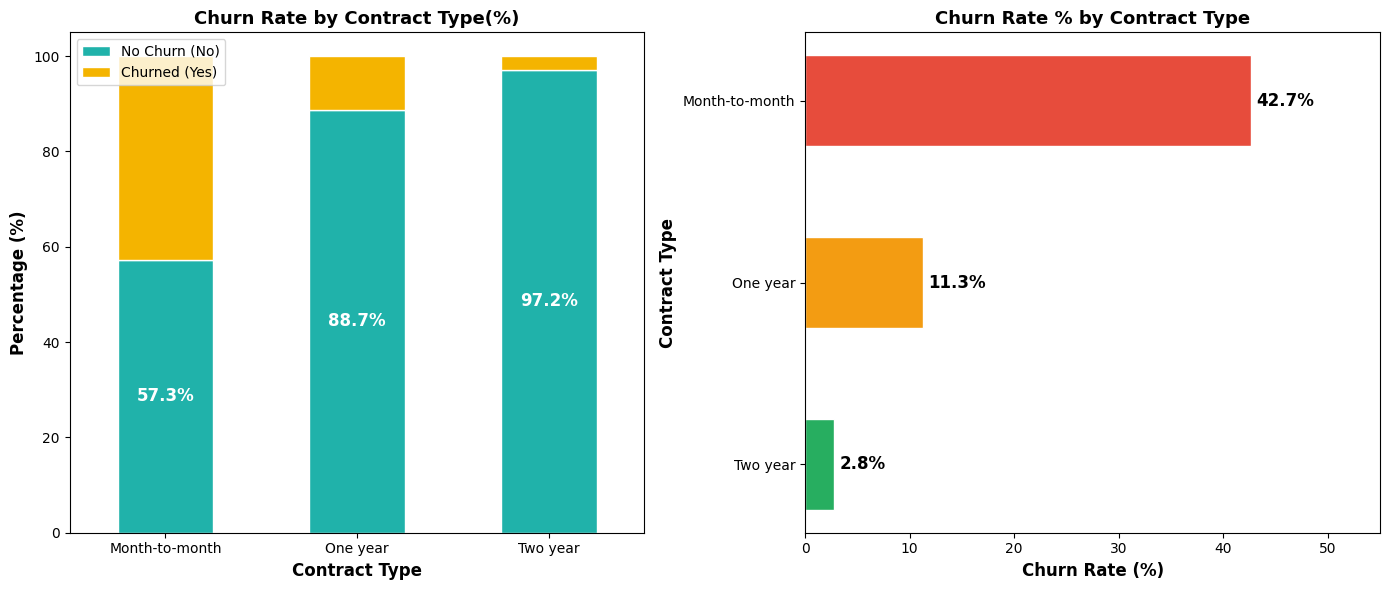


 CHURN BY CONTRACT TYPE RESULT:
─────────────────────────────────────────────
Month-to-month       → Churn Rate: 42.7%
One year             → Churn Rate: 11.3%
Two year             → Churn Rate: 2.8%


In [8]:
# Deep EDA: Churn by Contract Type
print("CHURN RATE BY CONTRACT TYPE:")
churn_by_contract = df_clean.groupby('Contract')['Churn'].value_counts(normalize = True).unstack()
print(churn_by_contract)

# ── ax[0]: Stacked Bar Chart 
churn_by_contract_pct = (churn_by_contract*100).round(1)  
print()  
print(churn_by_contract_pct)

fig, ax = plt.subplots(1, 2, figsize =(14, 6))
churn_by_contract_pct.plot(kind = 'bar', 
                           stacked = True, 
                           ax = ax[0],
                           color = ['#20B2AA', '#F4B400'],
                           edgecolor = 'white',
                           width = 0.5,
                           rot = 0)
ax[0].set_title('Churn Rate by Contract Type(%)',
                   fontsize=13, fontweight='bold')
ax[0].set_xlabel('Contract Type', fontsize=12,fontweight='bold')
ax[0].set_ylabel('Percentage (%)', fontsize=12,fontweight='bold')
ax[0].legend(['No Churn (No)', 'Churned (Yes)'], fontsize=10)

for i, (contract, row) in enumerate(churn_by_contract_pct.iterrows()):
    churn_pct = row[0]
    ax[0].text(i, churn_pct / 2,
                f'{churn_pct}%',
                 ha = 'center',
                 va = 'center',
                 fontweight='bold',
                 fontsize=12,
                 color='white' )
    
# ax[1] : Horizontal Bar Chart of Churn Rate Only
churn_only = churn_by_contract_pct[1].sort_values(ascending=True)
colors = ['#27ae60', '#f39c12', '#e74c3c']
bars = ax[1].barh(churn_only.index,
                  churn_only.values,
                  color = colors,
                  edgecolor='white',
                  height=0.5)
for bar, value in zip(bars, churn_only.values):
    ax[1].text(
        bar.get_width() + 0.5,
                bar.get_y() + bar.get_height()/2,
        f'{value:.1f}%',
        va='center',
        fontweight='bold',
        fontsize=12
    )

ax[1].set_title('Churn Rate % by Contract Type',
                   fontsize=13, fontweight='bold')
ax[1].set_xlabel('Churn Rate (%)', fontsize=12,fontweight='bold')
ax[1].set_ylabel('Contract Type', fontsize=12,fontweight='bold')
ax[1].set_xlim(0, 55)

plt.tight_layout()
plt.savefig('../outputs/02_churn_by_contract.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n CHURN BY CONTRACT TYPE RESULT:")
print("─" * 45)
for contract, row in churn_by_contract_pct.iterrows():
    print(f"{contract:20s} → Churn Rate: {row[1]:.1f}%")


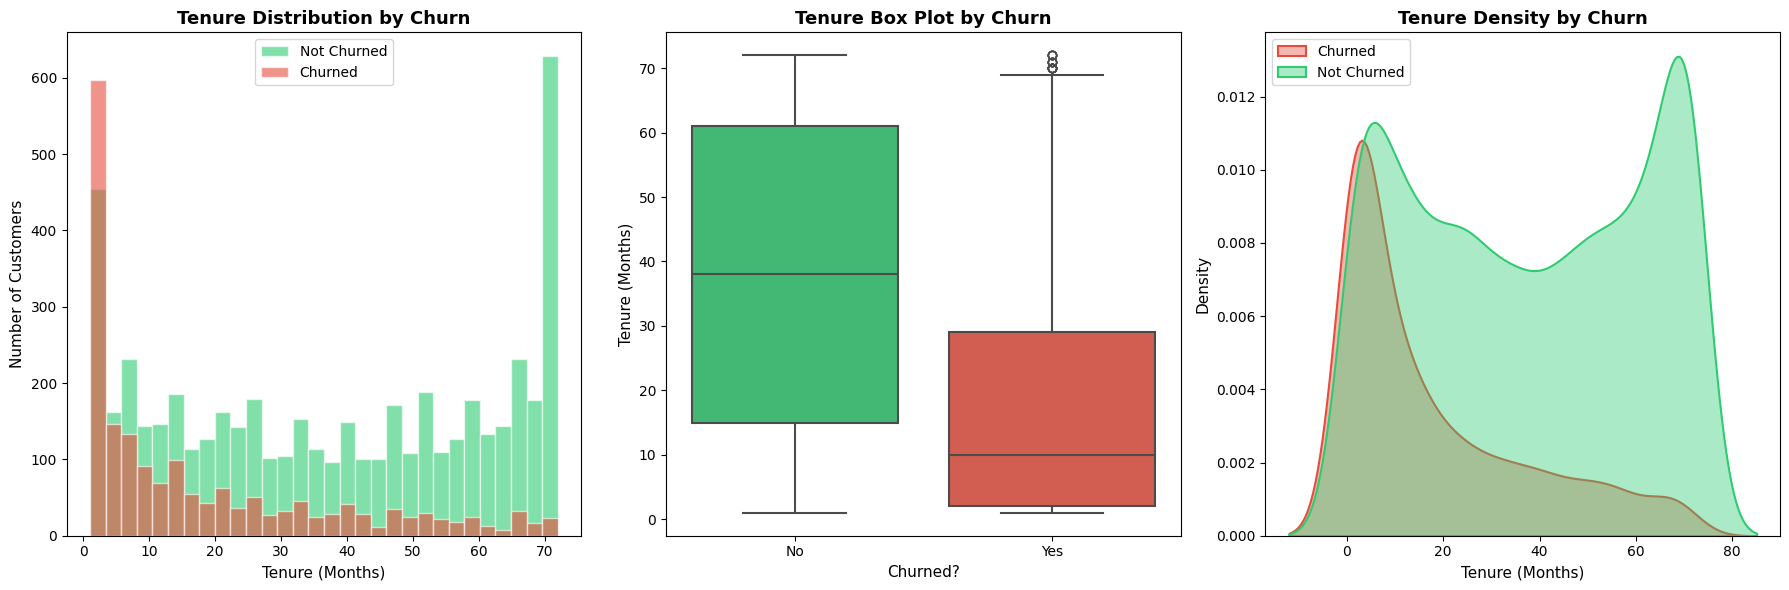


Churn BY Tenure:
─────────────────────────────────────────────
Not Churned  → Median tenure: 38 months
Churned → Median tenure: 10 months

Conclusion: Churners leave after only 10 months on average!


In [9]:
# Deep EDA: Churn BY Tenure

# Chart 1: Histogram
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

no_churn_tenure = df_clean[df_clean['Churn'] == 0]['tenure']
yes_churn_tenure = df_clean[df_clean['Churn'] == 1]['tenure']

axes[0].hist(no_churn_tenure, 
            bins = 30,
            alpha = 0.6, 
            color='#2ecc71',
            label='Not Churned',
            edgecolor='white')

axes[0].hist(yes_churn_tenure,
             bins = 30,
             alpha = 0.6,
             color='#e74c3c',
             label='Churned',
             edgecolor='white')

axes[0].set_title('Tenure Distribution by Churn',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Tenure (Months)', fontsize=11)
axes[0].set_ylabel('Number of Customers', fontsize=11)
axes[0].legend(fontsize=10)

#Chart 2: Box plot
sns.boxplot(x = 'Churn', 
            y = 'tenure',
            data = df_clean,
            ax = axes[1],
            palette={'1': '#e74c3c', '0': '#2ecc71'},
            linewidth = 1.5)

axes[1].set_title('Tenure Box Plot by Churn',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Churned?', fontsize=11)
axes[1].set_ylabel('Tenure (Months)', fontsize=11)
axes[1].set_xticklabels(['No', 'Yes'])

# Chart 3: KDE Plot (Smooth Distribution)
sns.kdeplot(data = df_clean, 
            x = 'tenure', 
            hue = 'Churn',  
            fill=True,
            ax = axes[2],
            alpha=0.4,
            linewidth = 1.5,
            palette={0: '#2ecc71', 1: '#e74c3c'})

axes[2].set_title('Tenure Density by Churn',
                   fontsize=13, fontweight='bold')
axes[2].set_xlabel('Tenure (Months)', fontsize=11)
axes[2].set_ylabel('Density', fontsize=11)
axes[2].legend(['Churned', 'Not Churned'], fontsize=10)

plt.tight_layout()
plt.savefig('../outputs/03_tenure_vs_churn.png', dpi=300, bbox_inches='tight')
plt.show()

print("\nChurn BY Tenure:")
print("─" * 45)
print(f"Not Churned  → Median tenure: "
      f"{no_churn_tenure.median():.0f} months")
print(f"Churned → Median tenure: "
      f"{yes_churn_tenure.median():.0f} months")
print(f"\nConclusion: Churners leave after only "
      f"{yes_churn_tenure.median():.0f} months on average!")

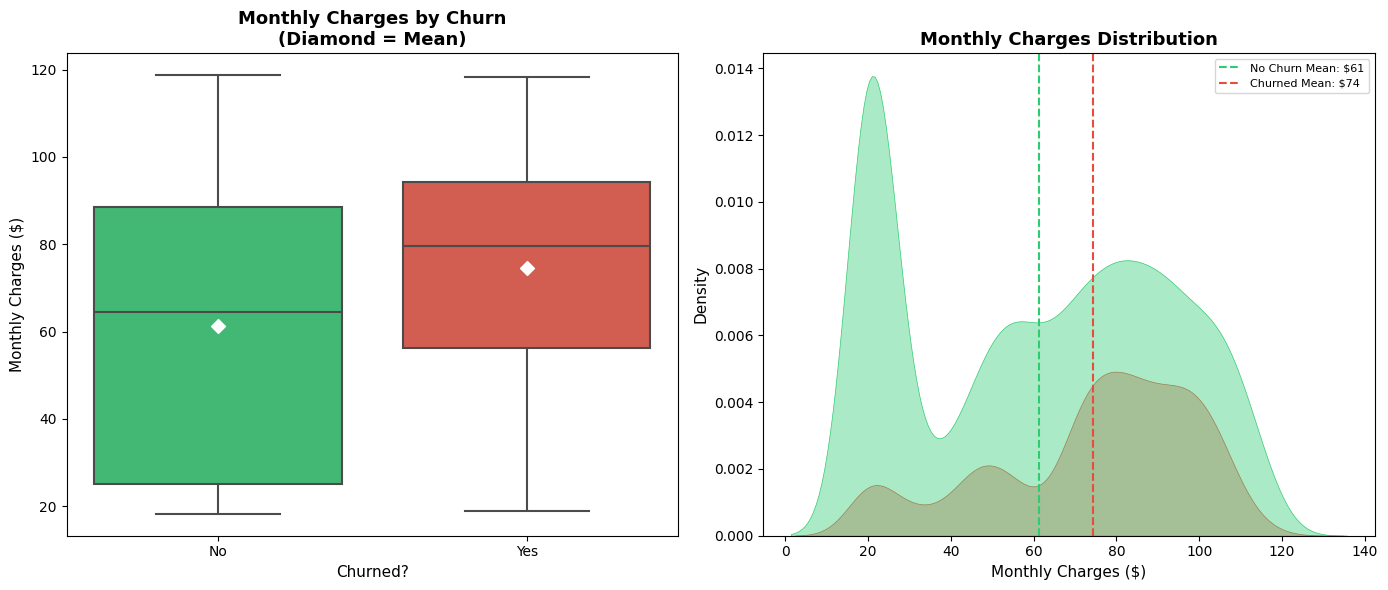


 Churn by Monthly Charges Results:
─────────────────────────────────────────────
Stayed  → Avg Monthly Charges: $61.31
Churned → Avg Monthly Charges: $74.44
Difference: $13.13 more per month for churners!


In [10]:
# Deep EDA: Churn by Monthly Charges 

# Chart 1: Box Plot with Mean Overlay
fig, axes = plt.subplots(1, 2, figsize = (14, 6))

sns.boxplot(x = 'Churn',
            y = 'MonthlyCharges',
            data = df_clean,
            ax = axes[0],
            palette={'0': '#2ecc71', '1': '#e74c3c'},
            linewidth = 1.5)
    
no_churn_mean = df_clean[df_clean['Churn'] == 0]['MonthlyCharges'].mean()
yes_churn_mean = df_clean[df_clean['Churn'] == 1]['MonthlyCharges'].mean()

axes[0].scatter([0, 1],
                [no_churn_mean, yes_churn_mean],
                marker = 'D',
                color = 'white',
                zorder = 3,
                s = 50)

axes[0].set_title('Monthly Charges by Churn\n'
                   '(Diamond = Mean)',
                   fontsize=13, fontweight='bold')
axes[0].set_xlabel('Churned?', fontsize=11)
axes[0].set_ylabel('Monthly Charges ($)', fontsize=11)
axes[0].set_xticklabels(['No', 'Yes'])

#Chart 2: KDE Plot
sns.kdeplot(data = df_clean,
            x = 'MonthlyCharges',
            hue = 'Churn',
            fill = True,    
            ax = axes[1],   
            alpha = 0.4,
            linewidth = 0.5,
            palette={0: '#2ecc71', 1: '#e74c3c'})    

axes[1].legend(['Churned', 'Not Churned'], fontsize=10)  

axes[1].axvline(               # axvline → draws a vertical line at x position
    x=no_churn_mean,
    color='#2ecc71',
    linestyle='--',   
    linewidth=1.5,
    label=f'No Churn Mean: ${no_churn_mean:.0f}'
)

axes[1].axvline(
    x=yes_churn_mean,
    color='#e74c3c',
    linestyle='--',
    linewidth=1.5,
    label=f'Churned Mean: ${yes_churn_mean:.0f}'
)

axes[1].set_title('Monthly Charges Distribution',
                   fontsize=13, fontweight='bold')
axes[1].set_xlabel('Monthly Charges ($)', fontsize=11)
axes[1].set_ylabel('Density', fontsize=11)
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/04_monthly_charges_churn.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\n Churn by Monthly Charges Results:")
print("─" * 45)
print(f"Stayed  → Avg Monthly Charges: ${no_churn_mean:.2f}")
print(f"Churned → Avg Monthly Charges: ${yes_churn_mean:.2f}")
print(f"Difference: ${yes_churn_mean - no_churn_mean:.2f} more "
      f"per month for churners!")

CORRELATION WITH CHURN (sorted high to low):
──────────────────────────────────────────────────
InternetService_Fiber optic              0.307
PaymentMethod_Electronic check           0.301
MonthlyCharges                           0.193
PaperlessBilling_Yes                     0.191
SeniorCitizen                            0.151
StreamingTV_Yes                          0.063
StreamingMovies_Yes                      0.061
MultipleLines_Yes                        0.040
PhoneService_Yes                         0.012
gender_Male                             -0.009
MultipleLines_No phone service          -0.012
DeviceProtection_Yes                    -0.066
OnlineBackup_Yes                        -0.082
PaymentMethod_Mailed check              -0.091
PaymentMethod_Credit card (automatic)   -0.135
Partner_Yes                             -0.150
Dependents_Yes                          -0.163
TechSupport_Yes                         -0.165
OnlineSecurity_Yes                      -0.171
Contract_On

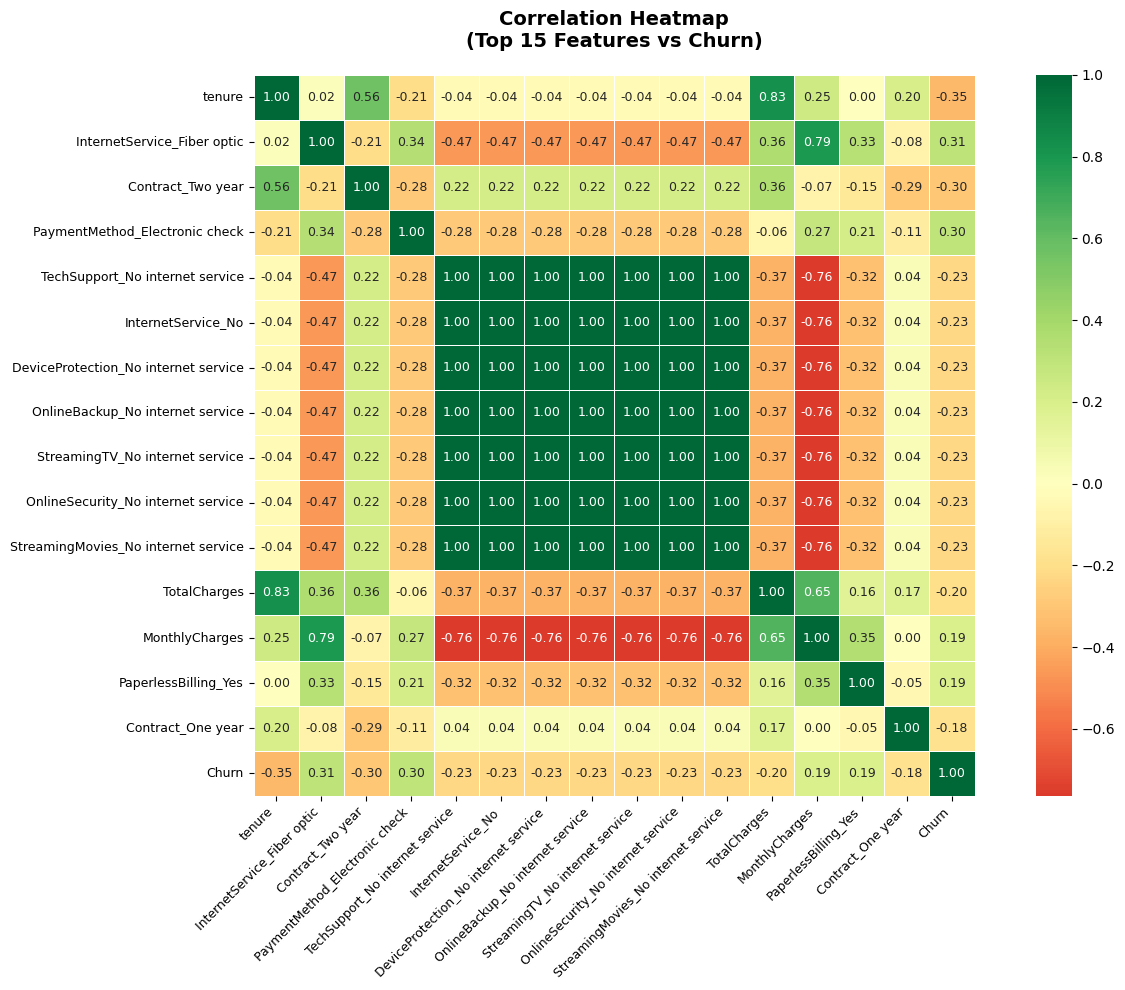


TOP 5 FEATURES POSITIVELY CORRELATED WITH CHURN:
──────────────────────────────────────────────────
InternetService_Fiber optic       0.307463
PaymentMethod_Electronic check    0.301455
MonthlyCharges                    0.192858
PaperlessBilling_Yes              0.191454
SeniorCitizen                     0.150541
Name: Churn, dtype: float64

TOP 5 FEATURES NEGATIVELY CORRELATED WITH CHURN:
──────────────────────────────────────────────────
DeviceProtection_No internet service   -0.227578
StreamingMovies_No internet service    -0.227578
TechSupport_No internet service        -0.227578
Contract_Two year                      -0.301552
tenure                                 -0.354049
Name: Churn, dtype: float64


In [11]:
# Deep EDA: Correlation Heatmap
correlation_matrix = df_encoded.corr()

churn_correlation = correlation_matrix['Churn'].drop('Churn').sort_values(ascending=False)

print("CORRELATION WITH CHURN (sorted high to low):")
print("─" * 50)
print(churn_correlation.round(3))

top_features = churn_correlation.abs().sort_values(ascending=False).head(15).index

top_features_with_churn = top_features.to_list() + ['Churn']
top_corr = df_encoded[top_features_with_churn].corr()

fig, ax = plt.subplots(figsize=(14, 10))

sns.heatmap(top_corr,
            annot = True,
            fmt = '.2f',
            cmap = 'RdYlGn',
            center = 0,
            linewidth = 0.5,
            annot_kws={'size': 9},
            ax = ax,
            square = True)

ax.set_title('Correlation Heatmap\n(Top 15 Features vs Churn)',
             fontsize=14, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right', fontsize=9)
plt.yticks(fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/05_correlation_heatmap.png',
            dpi=150, bbox_inches='tight')
plt.show()

print("\nTOP 5 FEATURES POSITIVELY CORRELATED WITH CHURN:")
print("─" * 50)
print(churn_correlation.head(5))
print("\nTOP 5 FEATURES NEGATIVELY CORRELATED WITH CHURN:")
print("─" * 50)
print(churn_correlation.tail(5))

In [12]:
# Deep EDA Summary

print("DEEP EDA COMPLETE — KEY FINDINGS SUMMARY")
print("=" * 55)

print("""
    1. MONTH-TO-MONTH CUSTOMERS CHURN MORE
       Month-to-month: 42.7% churn rate
       Two year:        2.9% churn rate
       Impact: 15x difference!)

    2. New customers churn more 
       Churners median tenure:  10 months
       Stayers  median tenure:  38 months
       Impact: First year is CRITICAL!
      
    3. Higher charges = more churn         
       Churners avg charge:  $74.44/month
       Stayers  avg charge:  $61.27/month
       Impact: $13 difference per month
      
      
      
    MOST IMPORTANT FEATURES FOR ML MODEL:
───────────────────────────────────────────────────────
1. tenure              (correlation: -0.35)
2. Contract_Two year   (correlation: -0.30)
3. MonthlyCharges      (correlation: +0.19)
4. TotalCharges        (correlation: -0.20)
5. Contract_One year   (correlation: -0.18)
      
      
      
    BUSINESS RECOMMENDATIONS:
───────────────────────────────────────────────────────
1. Focus retention efforts on first 12 months
2. Incentivize customers to sign longer contracts
3. Offer price-lock guarantees to high-paying customers
4. Create early warning system for month-to-month
   customers with high charges and low tenure
      """)

DEEP EDA COMPLETE — KEY FINDINGS SUMMARY

    1. MONTH-TO-MONTH CUSTOMERS CHURN MORE
       Month-to-month: 42.7% churn rate
       Two year:        2.9% churn rate
       Impact: 15x difference!)

    2. New customers churn more 
       Churners median tenure:  10 months
       Stayers  median tenure:  38 months
       Impact: First year is CRITICAL!

    3. Higher charges = more churn         
       Churners avg charge:  $74.44/month
       Stayers  avg charge:  $61.27/month
       Impact: $13 difference per month



    MOST IMPORTANT FEATURES FOR ML MODEL:
───────────────────────────────────────────────────────
1. tenure              (correlation: -0.35)
2. Contract_Two year   (correlation: -0.30)
3. MonthlyCharges      (correlation: +0.19)
4. TotalCharges        (correlation: -0.20)
5. Contract_One year   (correlation: -0.18)



    BUSINESS RECOMMENDATIONS:
───────────────────────────────────────────────────────
1. Focus retention efforts on first 12 months
2. Incentivize custom